In [1]:
from dtwa_non_integrated import run_dtwa
from fdt import calculate_correlations_and_responses
import jax.numpy as jnp
import jax 
import matplotlib.pyplot as plt 

# Dynamics

In [2]:
# Constant Parameters
p = {
    "n_spins": 1000,
    "omega_0": 1.0,
    "B_z": 1.0,
    "alpha": 0.05,
    "omega_c": 5.0,
    "s": 1.0,
    "g": 0.25,
    "T": 0.2,
    "initial_direction": jnp.array([0.01, 0.0, 0.99]),
    "n_photons_initial": 0.0, 
    "time_steps": 5_000,
    "frequency_steps": 5_000,
    "n_trajectories": 10_000,
    "batch_size": 10_000
}

key=jax.random.PRNGKey(42)
t_max = 400

_, subkey = jax.random.split(key)
dtwa_keys = jax.random.split(subkey, p['n_trajectories'])

# 1. Setup
t_grid = jnp.linspace(0, t_max, p["time_steps"])
dt = t_grid[1]-t_grid[0]
# Defining the magnetic field B along Z
B_field = jnp.zeros((p["time_steps"], 3)).at[:, 2].set(p["B_z"])
j_val = p["n_spins"] / 2.0


# --- KEY FIX ---
# split(key) returns two keys. We unpack them to get one "fresh" subkey.
_, subkey = jax.random.split(key)
# Now we split that single subkey into the required number of trajectories
dtwa_field_keys = jax.random.split(subkey, p['n_trajectories'])
# ----------------

# 3. Run Coupled Non-Markovian TWA Simulation
# This returns BOTH the spin trajectories and explicit cavity trajectories
stats = run_dtwa(
    keys=dtwa_field_keys, 
    t_grid=t_grid, 
    omega_0=p["omega_0"], 
    alpha=p["alpha"],
    omega_c=p["omega_c"], 
    s=p['s'], 
    T=p["T"], 
    B_field=B_field,
    g=p["g"], 
    n_photons_initial=p["n_photons_initial"],
    initial_direction=p["initial_direction"], 
    batch_size=p['batch_size'],
    n_spins=p["n_spins"],
    w_max=2*p['omega_c'],    # Default frequency grid cutoff
    N_w=p['frequency_steps'],      # Default frequency steps
    use_noise=True, 
    use_sampling=True
)

Executing 10000 trajectories across 1 compiled batches...
Simulation Complete!


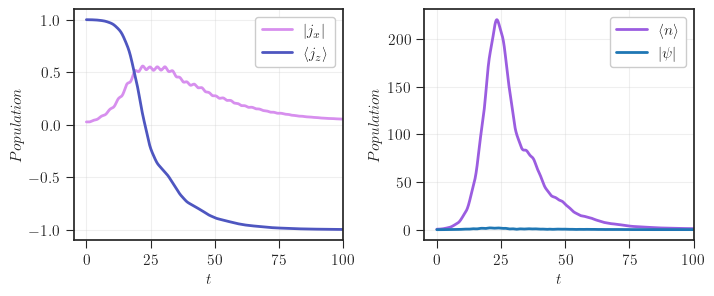

In [3]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.3)

ax[0].plot(t_grid, stats['abs_jx'], linewidth = 2, label = r'$\vert j_x \vert$', 
           color = '#D78FEE')
ax[0].plot(t_grid, stats['j_z'], linewidth = 2, label = r'$\langle j_z \rangle$',
           color = '#4E56C0')
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$t$')
ax[0].set_ylabel(r'$Population$')
ax[0].set_xlim(-5, 100)
ax[0].legend()

ax[1].plot(t_grid, jnp.real(stats['mean_photon_number']), linewidth = 2, label = r'$\langle n \rangle$', 
           color = '#9B5DE0')
ax[1].plot(t_grid, stats['abs_mean_psi'], linewidth = 2, label = r'$\vert \psi \vert$')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$t$')
ax[1].set_ylabel(r'$Population$')
ax[1].set_xlim(-5, 100)
ax[1].legend()

plt.savefig('dynamics.png', dpi = 300, bbox_inches='tight')
plt.show()

# Correlations and Response

In [4]:
t_pulse = 150

results = calculate_correlations_and_responses(
    keys = dtwa_field_keys, 
    t_grid=t_grid,
    p = p,
    t_pulse = t_pulse, 
    w_max = 2*p['omega_c']
)

Pass 1/3: Base...
Pass 2/3: Spin perturbation...
Pass 3/3: Cavity perturbation...
Fourier transforms...
Done!


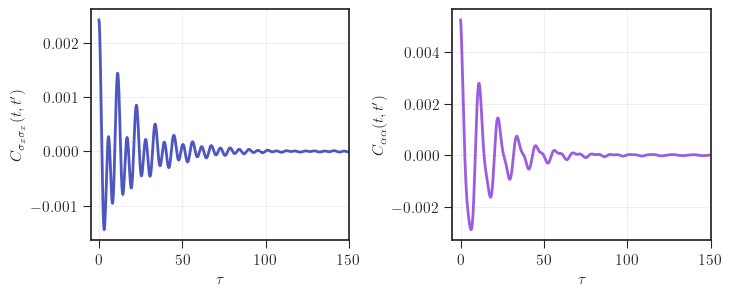

In [5]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].plot(results['tau_grid'], results['C_spin'], linewidth = 2, color = '#4E56C0')
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\tau$')
ax[0].set_xlim(-5, 150)
ax[0].set_ylabel(r"$C_{\sigma_x\sigma_x}(t, t')$")

ax[1].plot(results['tau_grid'], results['C_cavity'], linewidth = 2, color = '#9B5DE0')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\tau$')
ax[1].set_xlim(-5, 150)
ax[1].set_ylabel(r"$C_{\alpha\alpha}(t, t')$")

plt.savefig('integrated_correlations.png', dpi = 300, bbox_inches='tight')
plt.show()

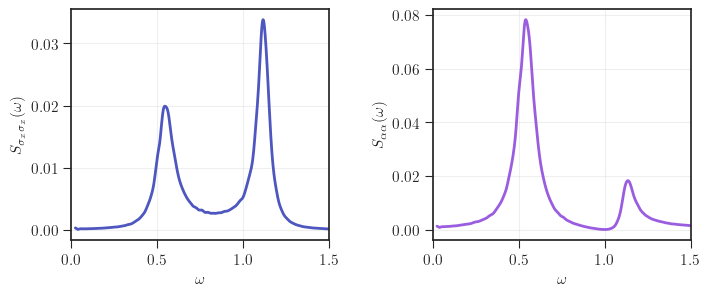

In [6]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].plot(results['w_grid'], results['S_c_spin'], linewidth = 2, color = '#4E56C0')
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\omega$')
ax[0].set_ylabel(r"$S_{\sigma_x\sigma_x}(\omega)$")
ax[0].set_xlim(0, 1.5)

ax[1].plot(results['w_grid'], results['S_c_cavity'], linewidth = 2, color = '#9B5DE0')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\omega$')
ax[1].set_ylabel(r"$S_{\alpha\alpha}(\omega)$")
ax[1].set_xlim(0, 1.5)

plt.savefig('correlations_spectrum.png', dpi = 300, bbox_inches='tight')
plt.show()

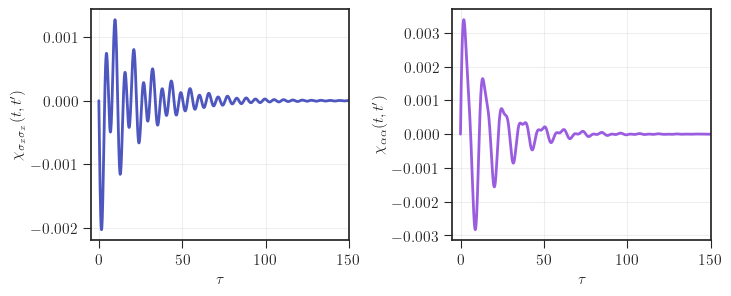

In [7]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].plot(results['tau_grid'], results['response_spin'], linewidth = 2, color = '#4E56C0')
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\tau$')
ax[0].set_xlim(-5, 150)
ax[0].set_ylabel(r"$\chi_{\sigma_x\sigma_x}(t, t')$")

ax[1].plot(results['tau_grid'], results['response_cavity'], linewidth = 2, color = '#9B5DE0')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\tau$')
ax[1].set_xlim(-5, 150)
ax[1].set_ylabel(r"$\chi_{\alpha\alpha}(t, t')$")
# 
plt.savefig('responses.png', dpi = 300, bbox_inches='tight')
plt.show()

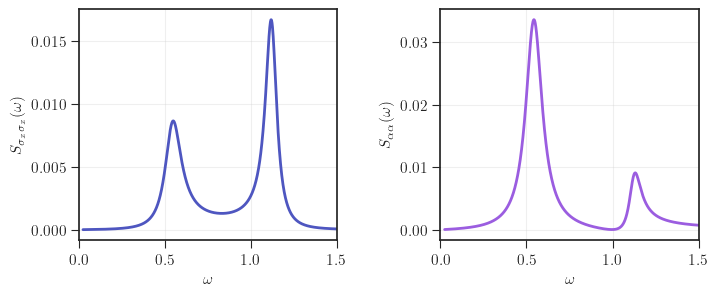

In [8]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].plot(results['w_grid'], -results['S_chi_spin'], linewidth = 2, color = '#4E56C0')
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\omega$')
ax[0].set_ylabel(r"$S_{\sigma_x\sigma_x}(\omega)$")
ax[0].set_xlim(0, 1.5)

ax[1].plot(results['w_grid'], results['S_chi_cavity'], linewidth = 2, color = '#9B5DE0')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\omega$')
ax[1].set_ylabel(r"$S_{\alpha\alpha}(\omega)$")
ax[1].set_xlim(0, 1.5)

plt.savefig('responses_spectrum.png', dpi = 300, bbox_inches='tight')
plt.show()

In [9]:
def compute_valid_ratio(S_c, S_chi, threshold_factor=1e-5, cap_value=1e6):
    """
    Computes the Fluctuation-Dissipation ratio S_c(w) / Im[Chi(w)].
    Masks out regions where the response signal is buried in numerical noise.
    
    Args:
        S_c: Symmetric correlation spectrum.
        S_chi: Imaginary part of the response spectrum.
        threshold_factor: The fraction of the peak signal considered to be the noise floor.
        cap_value: Maximum allowed ratio for physical zero-crossings inside the valid region.
        
    Returns:
        plot_safe_ratio: The ratio array with NaNs injected in dead zones.
        valid_mask: Boolean array indicating where the signal is physically meaningful.
    """
    # 1. Dynamically find the peak signal to establish a relative noise floor
    max_chi = jnp.max(jnp.abs(S_chi))
    threshold = threshold_factor * max_chi
    
    # 2. Identify the regions where the physical response actually exists
    valid_mask = jnp.abs(S_chi) > threshold
    
    # 3. Prevent division by zero by swapping invalid zeros with infinity
    safe_chi = jnp.where(valid_mask, S_chi, jnp.inf)
    raw_ratio = S_c / safe_chi
    
    # 4. Cap the massive asymptotes (useful for the spin's transient zero-crossing)
    capped_ratio = jnp.clip(raw_ratio, -cap_value, cap_value)
    
    # 5. Inject NaNs outside the valid regions so plotting libraries ignore them
    plot_safe_ratio = jnp.where(valid_mask, capped_ratio, jnp.nan)
    
    return plot_safe_ratio, valid_mask

In [10]:
# Prevent division by zero at the DC limit
w_safe = jnp.where(results['w_grid'] == 0, 1e-12, results['w_grid'])
quantum_ratio = 1.0 / jnp.tanh(w_safe / (2.0 * p['T']))
classical_ratio = (2.0 * p['T']) / w_safe

ratio_spin, valid_spin = compute_valid_ratio(results['S_c_spin'], -results['S_chi_spin'], threshold_factor=1e-5)
ratio_cavity, valid_cavity = compute_valid_ratio(results['S_c_cavity'], results['S_chi_cavity'], threshold_factor=1e-6)

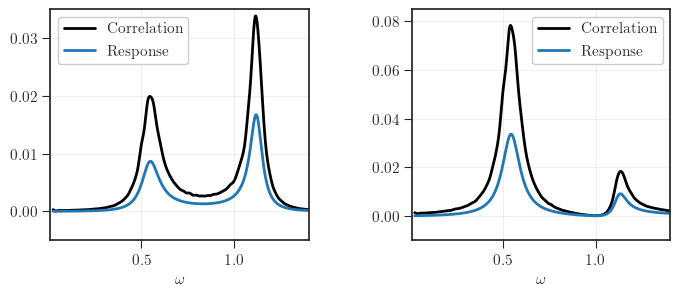

In [11]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].plot(results['w_grid'], results['S_c_spin'], linewidth = 2, label = 'Correlation', color = 'k')
ax[0].plot(results['w_grid'], -results['S_chi_spin'], linewidth = 2, label = 'Response')
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\omega$')
ax[0].set_xlim(0.01, 1.4)
ax[0].set_ylim(-0.005, 0.035)
ax[0].legend()

ax[1].plot(results['w_grid'], results['S_c_cavity'], linewidth = 2, label = 'Correlation', color = 'k')
ax[1].plot(results['w_grid'], results['S_chi_cavity'], linewidth = 2, label = 'Response')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\omega$')
ax[1].set_xlim(0.01, 1.4)
ax[1].set_ylim(-0.01, 0.085)
ax[1].legend()

plt.show()

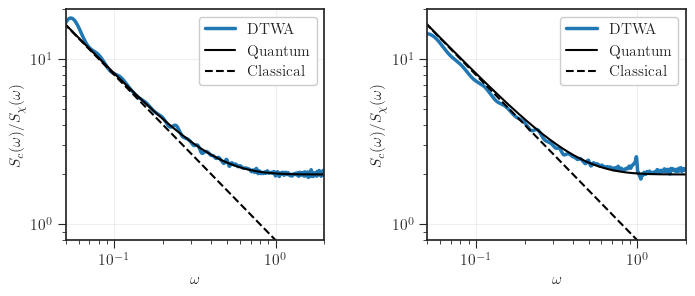

In [12]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].semilogy(results['w_grid'], ratio_spin, linewidth = 2.5, label = 'DTWA')
ax[0].loglog(results['w_grid'], 2*quantum_ratio, linewidth = 1.5, label = 'Quantum', color = 'k')
ax[0].semilogy(results['w_grid'], 2*classical_ratio, linewidth = 1.5, label = 'Classical', color = 'k', linestyle = '--')
ax[0].grid(alpha = 0.3)
ax[0].set_xlabel(r'$\omega$')
ax[0].set_ylabel(r"$S_{c}(\omega)/S_{\chi}(\omega)$")
ax[0].set_ylim(0.8, 0.2e2)
ax[0].set_xlim(0.05, 2.0)
ax[0].legend()

ax[1].semilogy(results['w_grid'], ratio_cavity, linewidth = 2.5, label = 'DTWA')
ax[1].loglog(results['w_grid'], 2*quantum_ratio, linewidth = 1.5, label = 'Quantum', color = 'k')
ax[1].semilogy(results['w_grid'], 2*classical_ratio, linewidth = 1.5, label = 'Classical', color = 'k', linestyle = '--')
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel(r'$\omega$')
ax[1].set_ylabel(r"$S_{c}(\omega)/S_{\chi}(\omega)$")
ax[1].set_ylim(0.8, 0.2e2)
ax[1].set_xlim(0.05, 2.0)
ax[1].legend()

plt.show()

# Phase transition

In [27]:
g_list = jnp.linspace(0.1, 0.8, 20)  
T_list = [0.01, 0.5, 1.5]
results = {T: {"g": [], "spin": [], "cavity": []} for T in T_list}

# Constant Parameters
p = {
    "n_spins": 30,
    "omega_0": 1.0,
    "B_z": 1.0,
    "alpha": 0.10,
    "omega_c": 5.0,
    "s": 1.0,
    "g": 0.35,
    "T": 1.0,
    "initial_direction": jnp.array([0.01, 0.0, 0.99]),
    "n_photons_initial": 0.0,  # Explicitly empty cavity (vacuum state)
    "n_steps": 5_000,
    "n_trajectories": 5_000,
    "batch_size": 5_000
}

key=jax.random.PRNGKey(42)
t_max = 500

_, subkey = jax.random.split(key)
dtwa_keys = jax.random.split(subkey, p['n_trajectories'])

# 1. Setup
t_grid = jnp.linspace(0, t_max, p["n_steps"])
dt = t_grid[1]-t_grid[0]
# Defining the magnetic field B along Z
B_field = jnp.zeros((p["n_steps"], 3)).at[:, 2].set(p["B_z"])
j_val = p["n_spins"] / 2.0

B_x_seed = 1e-4

for T in T_list:
    print(f"--- Running Sweep for T = {T} ---")
    for g in g_list:
        p["g"] = g
        p["T"] = T
        
        # Fresh keys for each run
        _, run_subkey = jax.random.split(key)
        dtwa_field_keys = jax.random.split(run_subkey, p['n_trajectories'])
        
        # B_field must be re-initialized
        B_field = jnp.zeros((p["n_steps"], 3))
        B_field = B_field.at[:, 0].set(B_x_seed)
        B_field = B_field.at[:, 2].set(p["B_z"])
        
        # Execute
        stats = run_dtwa(
            keys=dtwa_field_keys, 
            t_grid=t_grid, 
            omega_0=p["omega_0"], 
            alpha=p["alpha"],
            omega_c=p["omega_c"], 
            s=p['s'], 
            T=p["T"], 
            B_field=B_field,
            g=p["g"], 
            n_photons_initial=p["n_photons_initial"],
            initial_direction=p["initial_direction"], 
            batch_size=p['batch_size'],
            n_spins=p["n_spins"],
            w_max=jnp.pi/dt,
            N_w=5_000,
            use_noise=True, 
            use_sampling=True
        )
        
        # Extract and average the last 100 steps to get steady-state order parameters
        # This removes high-frequency transient wiggles
        spin_op = jnp.mean(stats["rms_jx"][-25:])
        cav_op = jnp.mean(stats["mean_photon_number"][-25:])
        
        results[T]["g"].append(g)
        results[T]["spin"].append(spin_op)
        results[T]["cavity"].append(cav_op)

--- Running Sweep for T = 0.01 ---
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories across 1 compiled batches...
Simulation Complete!
Executing 5000 trajectories a

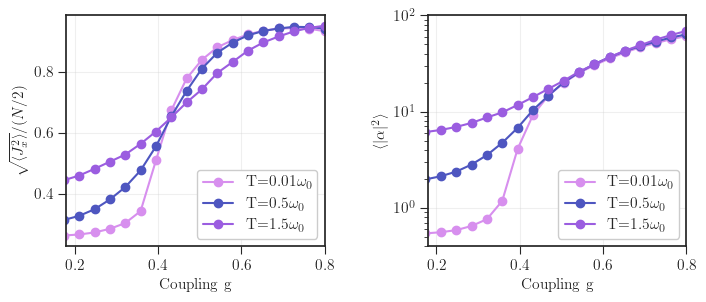

In [77]:
plt.style.use(['seaborn-v0_8-white', './style.mplstyle'])

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
plt.subplots_adjust(wspace=0.4)

colors = ['#D78FEE', '#4E56C0', '#9B5DE0']

i = 0
for T in T_list:
    ax[0].plot(results[T]["g"], results[T]["spin"], 'o-', label=fr"T={T}$\omega_0$", color = colors[i])
    ax[1].semilogy(results[T]["g"], results[T]["cavity"], 'o-', label=fr"T={T}$\omega_0$", color = colors[i])
    i += 1

ax[0].grid(alpha = 0.3)
ax[0].set_xlabel("Coupling g")
ax[0].set_ylabel(r"$\sqrt{\langle J_x^2 \rangle} / (N/2)$")
ax[0].set_xlim(0.18, 0.8)
ax[0].legend()

ax[1].grid(alpha = 0.3)
ax[1].set_xlabel("Coupling g")
ax[1].set_ylabel(r"$\langle |\alpha|^2 \rangle$")
ax[1].set_xlim(0.18, 0.8)
ax[1].set_ylim(0.4, 1e2)
ax[1].legend()

plt.savefig('phase_transition.png', dpi = 300, bbox_inches='tight')
plt.show()